Setup complete.
Loaded 2015: 30 teams
Loaded 2016: 30 teams
Loaded 2017: 30 teams
Loaded 2018: 30 teams
Loaded 2019: 30 teams
Loaded 2020: 30 teams
Loaded 2021: 30 teams
Loaded 2022: 30 teams
Loaded 2023: 30 teams
Loaded 2024: 30 teams

Final dataset: 300 team-seasons across 10 seasons
                     Team  SEASON     W     L    WL_PCT    PTS   AST   TOV  \
0   Golden State Warriors    2015  67.0  15.0  0.817073  110.0  27.4  14.5   
1    Los Angeles Clippers    2015  56.0  26.0  0.682927  106.7  24.8  12.3   
2       San Antonio Spurs    2015  55.0  27.0  0.670732  103.2  24.4  14.0   
3           Atlanta Hawks    2015  60.0  22.0  0.731707  102.5  25.7  14.2   
4     Cleveland Cavaliers    2015  53.0  29.0  0.646341  103.1  22.1  14.3   
5  Portland Trail Blazers    2015  51.0  31.0  0.621951  102.8  21.9  13.6   
6         Houston Rockets    2015  56.0  26.0  0.682927  103.9  22.2  16.7   
7       Memphis Grizzlies    2015  55.0  27.0  0.670732   98.3  21.7  13.3   
8         T

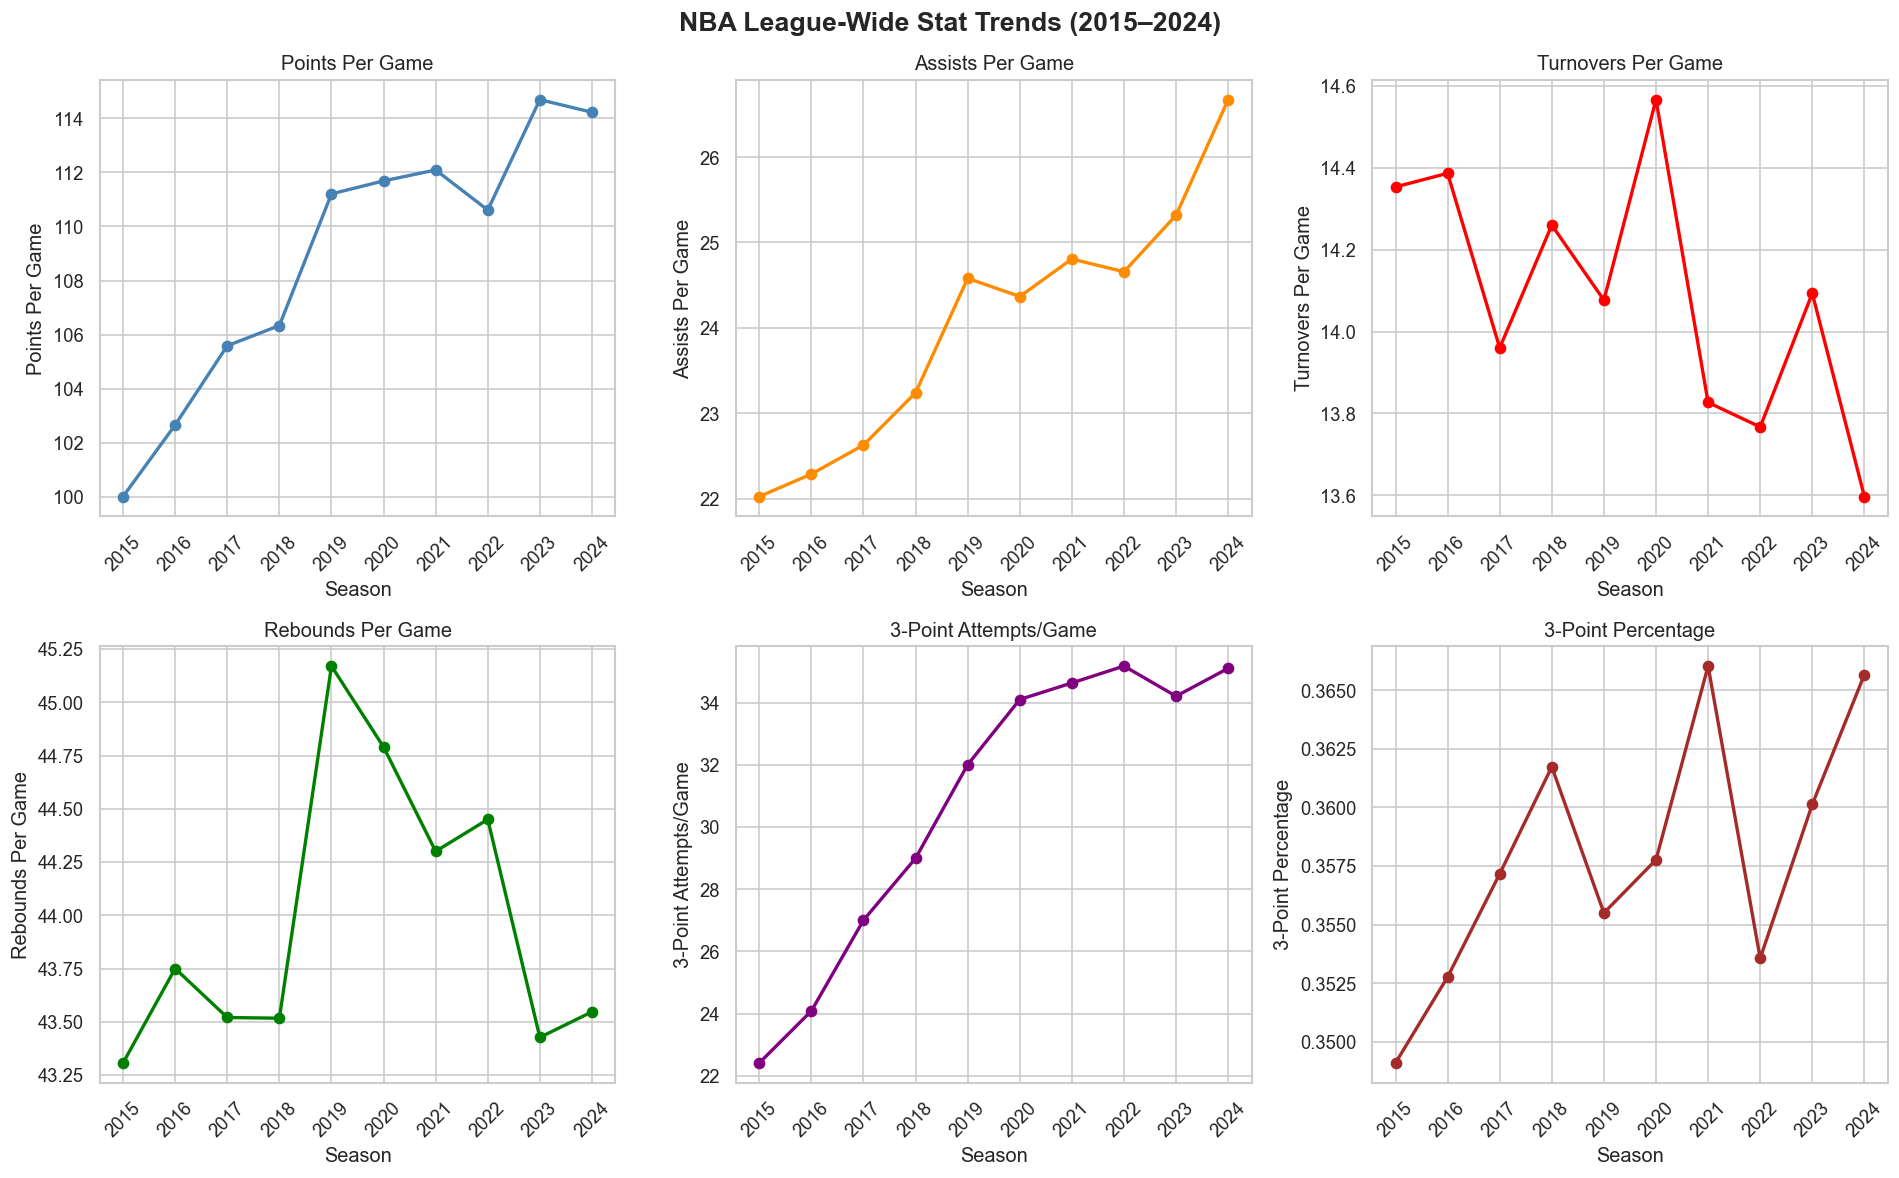

Saved viz1_league_trends.pdf


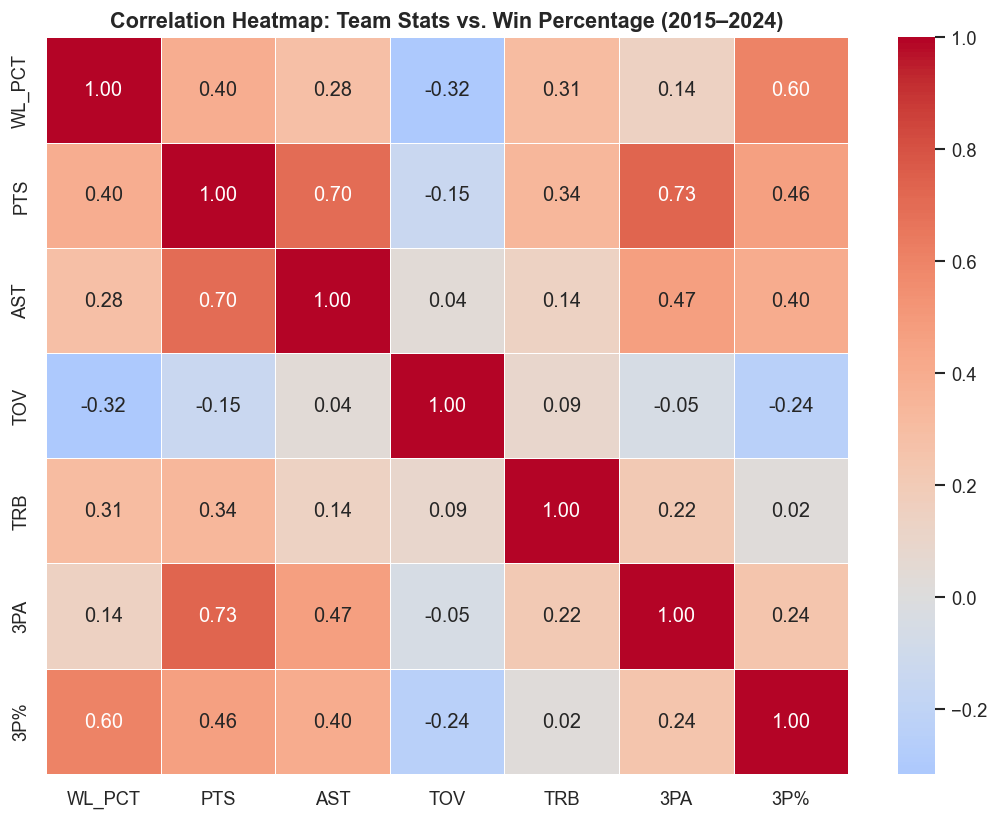

Saved viz2_correlation_heatmap.pdf


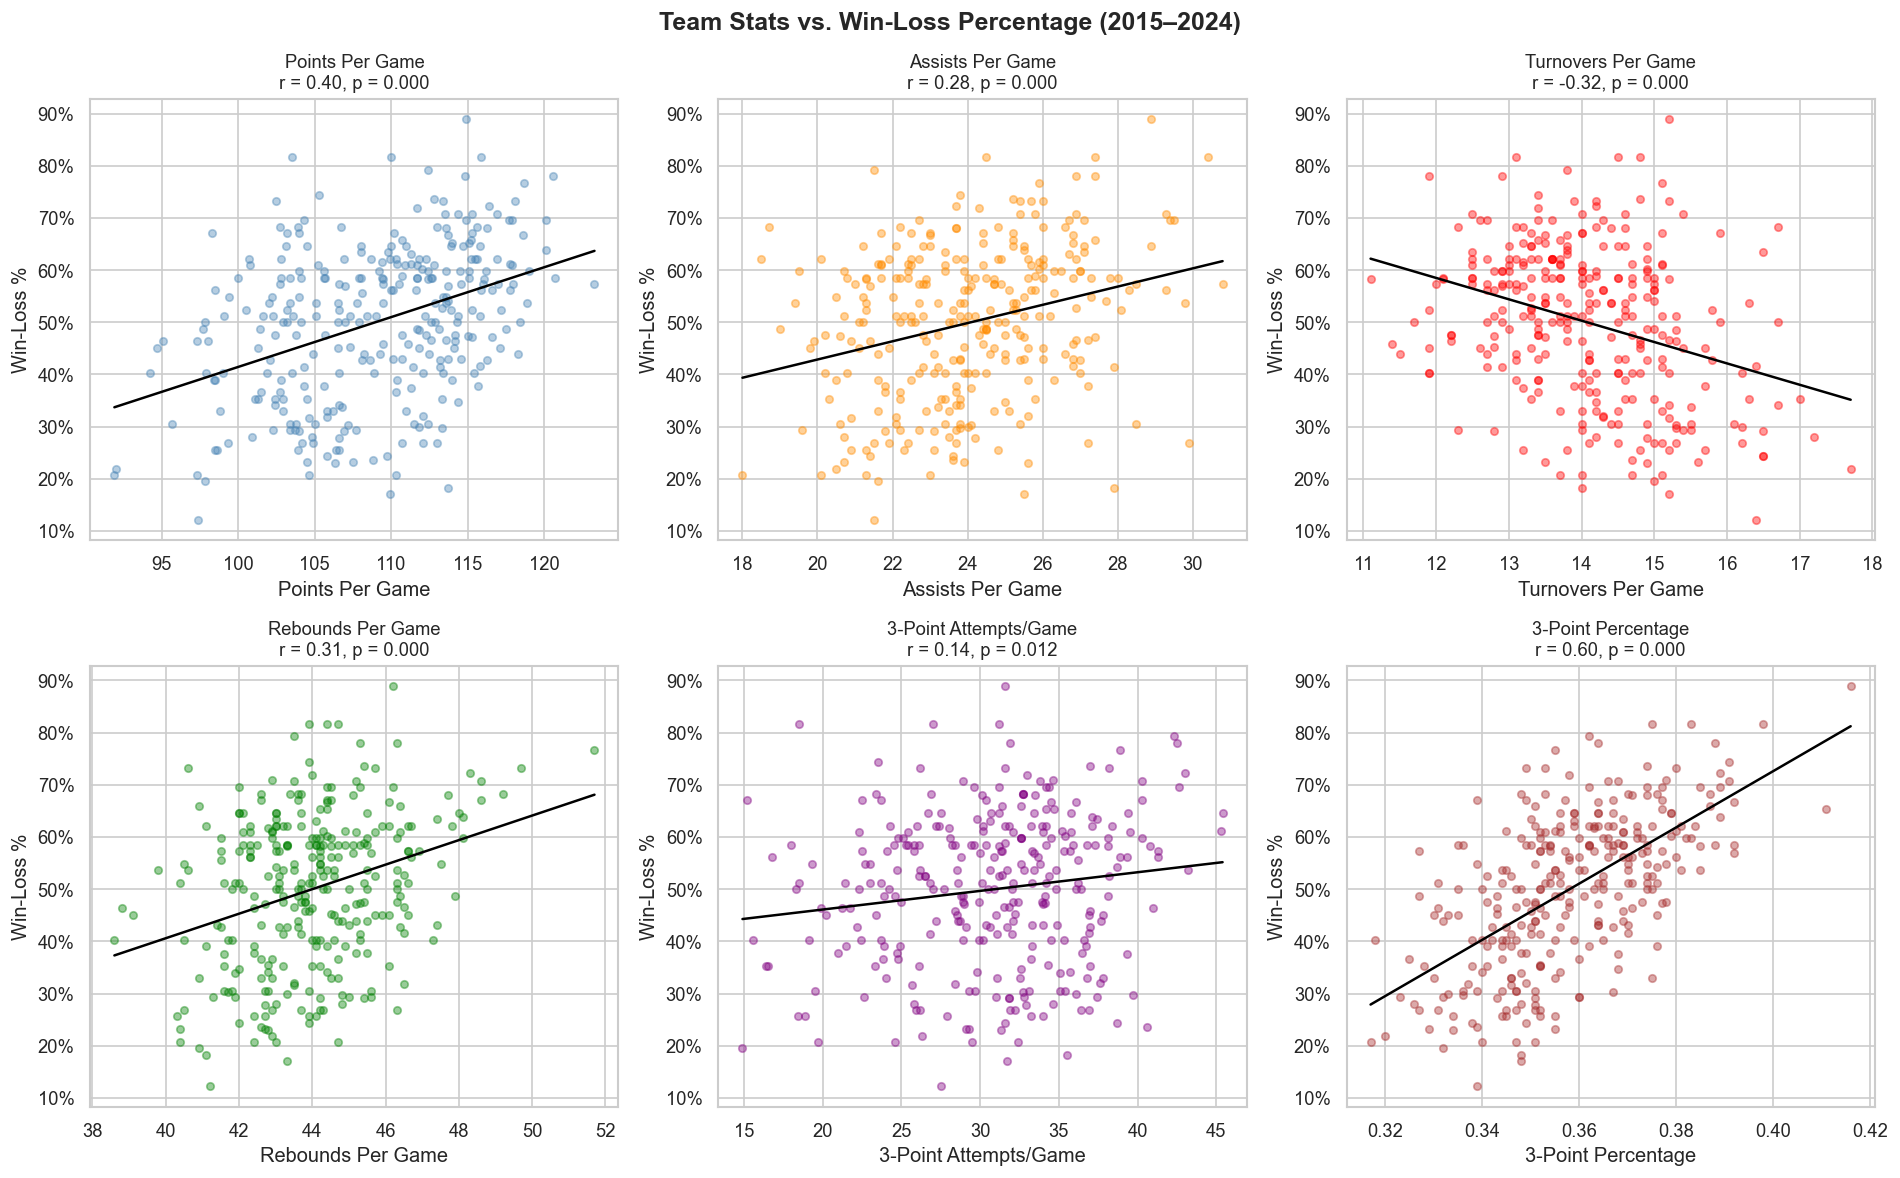

Saved viz3_scatter_plots.pdf
Opponent PTS column not found — skipping viz 4.


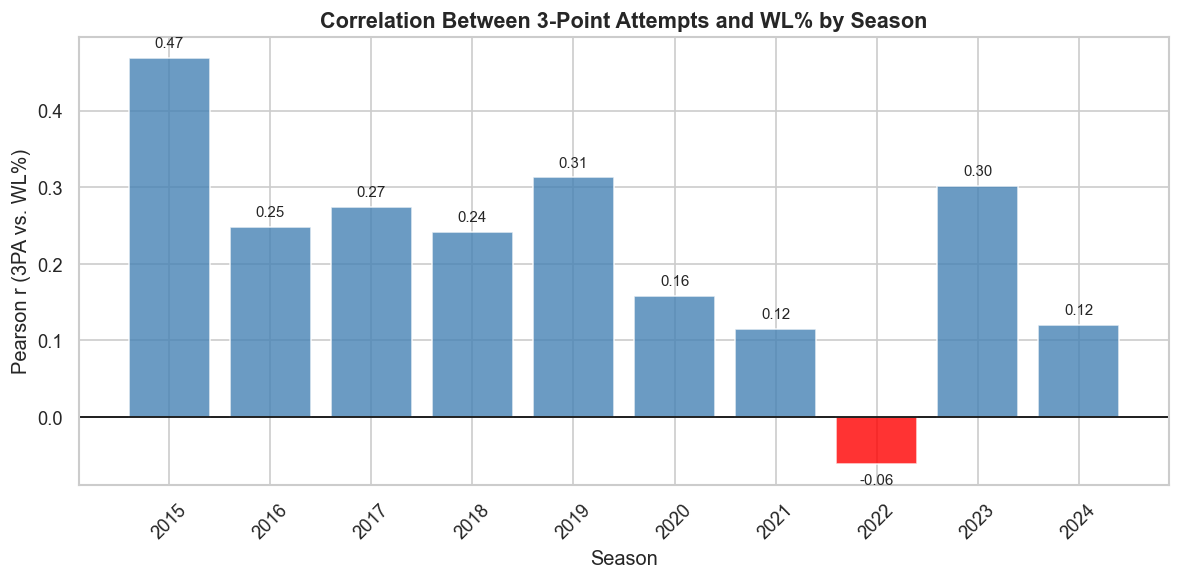

Saved viz5_3pt_revolution.pdf


/var/folders/4r/jfl1vxw92cv7th26bpfxh6_c0000gq/T/ipykernel_92786/1971305499.py:227: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_avg = raw_sorted.groupby("TIER")[["PTS", "AST", "TOV", "TRB", "3PA", "3P%"]].mean()


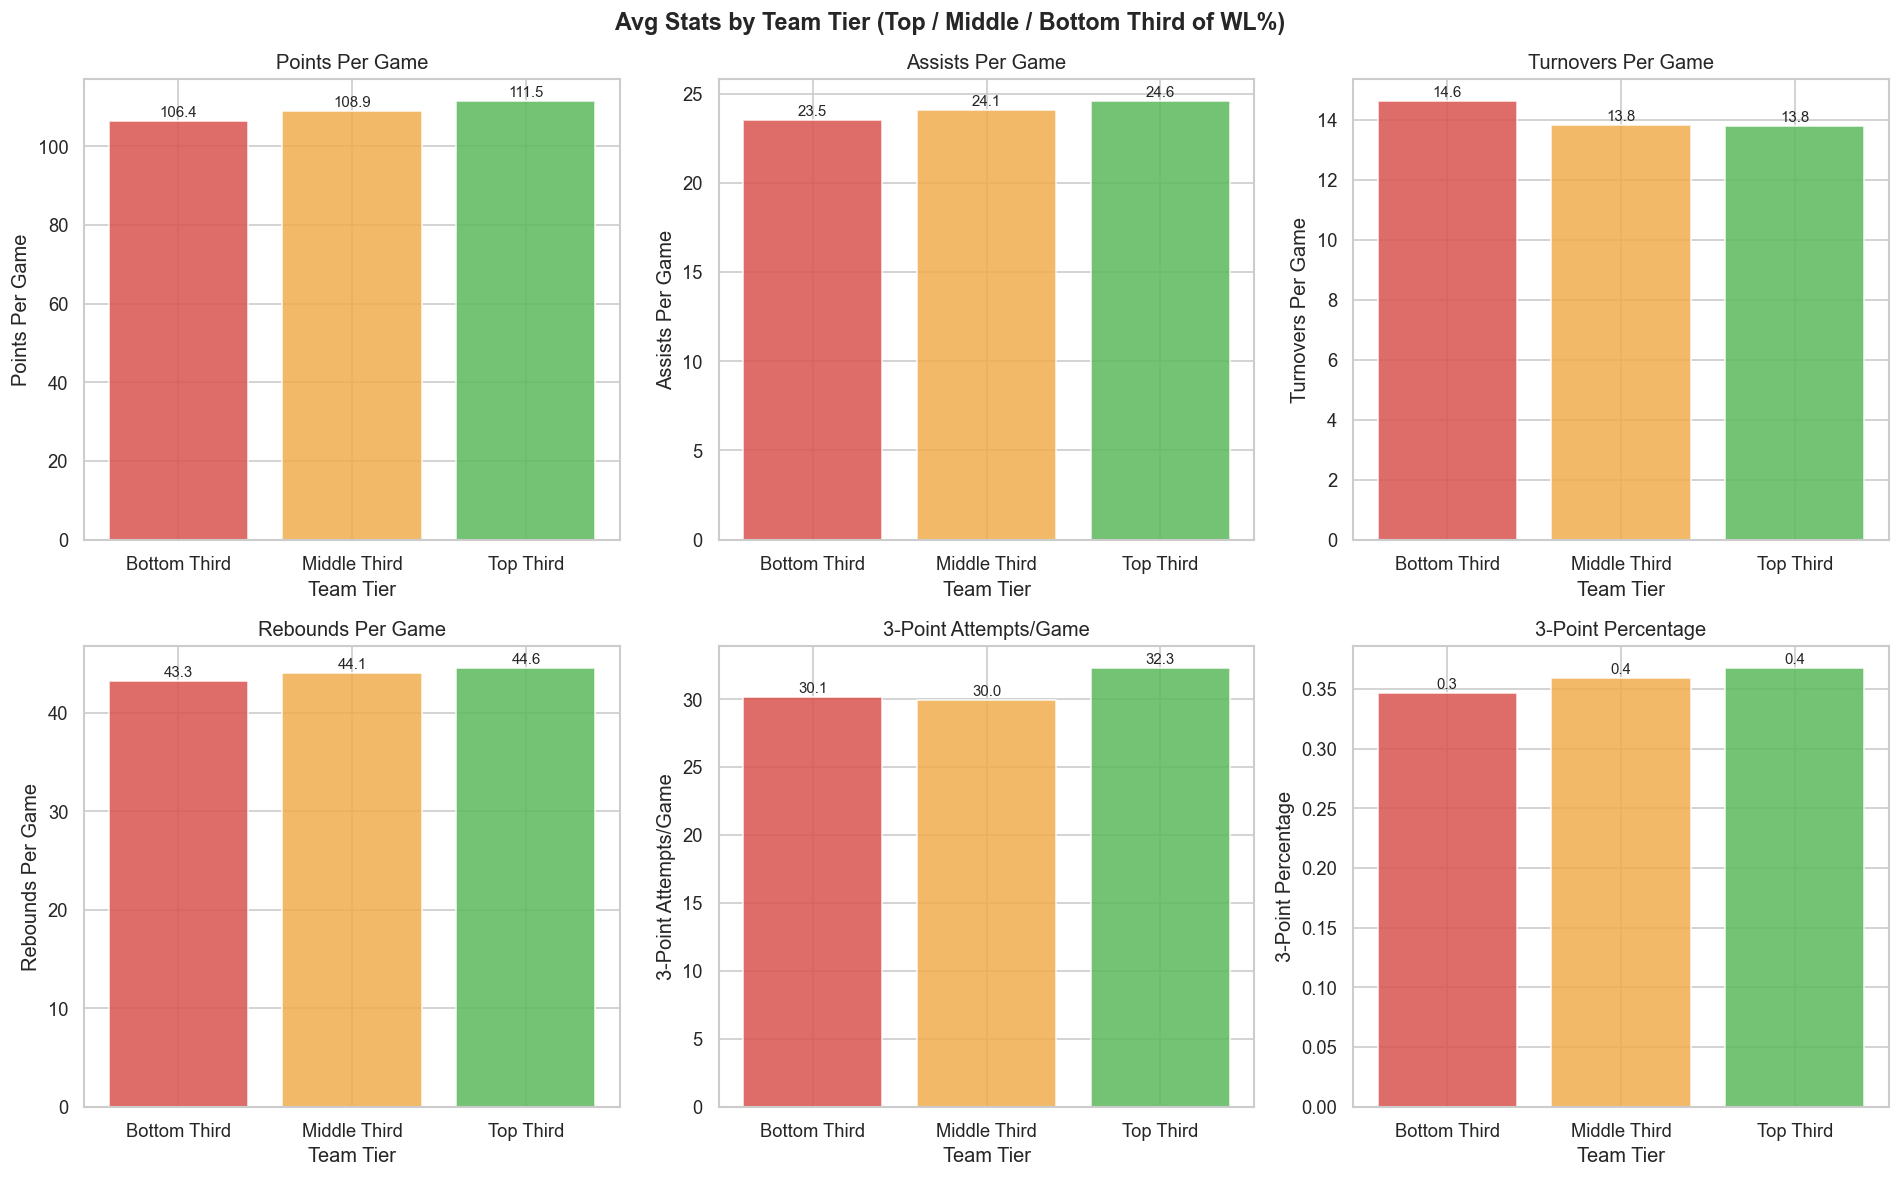

Saved viz6_tier_comparison.pdf
KEY FINDINGS
Points Per Game              r = +0.395  (positive, significant)
Assists Per Game             r = +0.281  (positive, significant)
Turnovers Per Game           r = -0.317  (negative, significant)
Rebounds Per Game            r = +0.306  (positive, significant)
3-Point Attempts/Game        r = +0.145  (positive, significant)
3-Point Percentage           r = +0.605  (positive, significant)


CONCLUSIONS:
1. Scoring (PTS) and point differential are the strongest predictors of 
   winning — teams that outscore opponents win far more often.

2. Assists have a meaningful positive correlation with WL%, confirming 
   that ball movement and team play lead to more wins.

3. Turnovers are negatively correlated with winning — giving the ball 
   away directly costs possessions and points.

4. 3-point attempts have grown dramatically since 2015, but their 
   correlation with winning has weakened in recent seasons, suggesting 
   the league has caught up 

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import time

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 6)

print("Setup complete.")

seasons = list(range(2015, 2025))  # 2014-15 through 2023-24
all_frames = []

for season in seasons:
    url = f"https://www.basketball-reference.com/leagues/NBA_{season}.html"
    try:
        tables = pd.read_html(url)

        # Find the advanced table (has W and L in multi-level columns)
        adv_idx = None
        for i, t in enumerate(tables):
            cols = [col[1] if isinstance(col, tuple) else col for col in t.columns]
            if "W" in cols and "L" in cols and "Team" in cols:
                adv_idx = i
                break

        # Find the per-game table (has PTS, AST, TOV as flat columns)
        pg_idx = None
        for i, t in enumerate(tables):
            if "PTS" in t.columns and "AST" in t.columns and "TOV" in t.columns:
                pg_idx = i
                break

        if adv_idx is None or pg_idx is None:
            print(f"Could not find required tables for {season}")
            continue

        # --- Advanced table: W, L ---
        adv = tables[adv_idx].copy()
        adv.columns = [col[1] if isinstance(col, tuple) else col for col in adv.columns]
        adv = adv[adv["Team"].notna()]
        adv = adv[adv["Team"] != "Team"]
        adv["Team"] = adv["Team"].str.replace("*", "", regex=False).str.strip()
        adv = adv[~adv["Team"].str.contains("League Average", na=False)]
        for col in ["W", "L"]:
            adv[col] = pd.to_numeric(adv[col], errors="coerce")
        adv = adv[["Team", "W", "L"]].dropna()

        # --- Per-game table: PTS, AST, TOV, TRB, 3PA, 3P% ---
        pg = tables[pg_idx].copy()
        pg = pg[pg["Team"].notna()]
        pg = pg[pg["Team"] != "Team"]
        pg["Team"] = pg["Team"].str.replace("*", "", regex=False).str.strip()
        pg = pg[~pg["Team"].str.contains("League Average", na=False)]
        for col in ["PTS", "AST", "TOV", "TRB", "3PA", "3P%"]:
            pg[col] = pd.to_numeric(pg[col], errors="coerce")
        pg = pg[["Team", "PTS", "AST", "TOV", "TRB", "3PA", "3P%"]].dropna()

        # Merge the two tables on Team
        df = adv.merge(pg, on="Team", how="inner")
        df["SEASON"] = season
        all_frames.append(df)
        print(f"Loaded {season}: {len(df)} teams")
        time.sleep(6)  # longer sleep to avoid rate limiting

    except Exception as e:
        print(f"Error loading {season}: {e}")

# Concatenate all seasons
raw = pd.concat(all_frames, ignore_index=True)
raw["WL_PCT"] = raw["W"] / (raw["W"] + raw["L"])
raw["SEASON"] = raw["SEASON"].astype(int)

print(f"\nFinal dataset: {raw.shape[0]} team-seasons across {raw['SEASON'].nunique()} seasons")
print(raw[["Team", "SEASON", "W", "L", "WL_PCT", "PTS", "AST", "TOV", "TRB", "3PA", "3P%"]].head(10))

league_avg = raw.groupby("SEASON")[["PTS", "AST", "TOV", "TRB", "3PA", "3P%"]].mean()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("NBA League-Wide Stat Trends (2015–2024)", fontsize=16, fontweight="bold")

configs = [
    ("PTS",  "Points Per Game",       "steelblue"),
    ("AST",  "Assists Per Game",      "darkorange"),
    ("TOV",  "Turnovers Per Game",    "red"),
    ("TRB",  "Rebounds Per Game",     "green"),
    ("3PA",  "3-Point Attempts/Game", "purple"),
    ("3P%",  "3-Point Percentage",    "brown"),
]

for ax, (col, label, color) in zip(axes.flatten(), configs):
    ax.plot(league_avg.index, league_avg[col], marker="o", color=color, linewidth=2)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("Season")
    ax.set_ylabel(label)
    ax.set_xticks(league_avg.index)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("viz1_league_trends.pdf", bbox_inches="tight")
plt.show()
print("Saved viz1_league_trends.pdf")


corr_cols = ["WL_PCT", "PTS", "AST", "TOV", "TRB", "3PA", "3P%"]
corr_matrix = raw[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    linewidths=0.5
)
ax.set_title("Correlation Heatmap: Team Stats vs. Win Percentage (2015–2024)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz2_correlation_heatmap.pdf", bbox_inches="tight")
plt.show()
print("Saved viz2_correlation_heatmap.pdf")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Team Stats vs. Win-Loss Percentage (2015–2024)", fontsize=15, fontweight="bold")

scatter_configs = [
    ("PTS",  "Points Per Game",        "steelblue"),
    ("AST",  "Assists Per Game",       "darkorange"),
    ("TOV",  "Turnovers Per Game",     "red"),
    ("TRB",  "Rebounds Per Game",      "green"),
    ("3PA",  "3-Point Attempts/Game",  "purple"),
    ("3P%",  "3-Point Percentage",     "brown"),
]

for ax, (col, label, color) in zip(axes.flatten(), scatter_configs):
    ax.scatter(raw[col], raw["WL_PCT"], alpha=0.4, color=color, s=20)

    # Add regression line
    slope, intercept, r, p, _ = stats.linregress(
        raw[col].dropna(), raw.loc[raw[col].notna(), "WL_PCT"]
    )
    x_line = np.linspace(raw[col].min(), raw[col].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color="black", linewidth=1.5)

    ax.set_title(f"{label}\nr = {r:.2f}, p = {p:.3f}", fontsize=11)
    ax.set_xlabel(label)
    ax.set_ylabel("Win-Loss %")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig("viz3_scatter_plots.pdf", bbox_inches="tight")
plt.show()
print("Saved viz3_scatter_plots.pdf")

# Get opponent points — look for OPP or opp column
opp_col = [c for c in raw.columns if "opp" in c.lower() or c == "Opp."]
if opp_col:
    raw["OPP_PTS"] = pd.to_numeric(raw[opp_col[0]], errors="coerce")
    raw["PT_DIFF"] = raw["PTS"] - raw["OPP_PTS"]

    slope, intercept, r, p, _ = stats.linregress(
        raw["PT_DIFF"].dropna(),
        raw.loc[raw["PT_DIFF"].notna(), "WL_PCT"]
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    scatter = ax.scatter(raw["PT_DIFF"], raw["WL_PCT"],
                         c=raw["SEASON"], cmap="viridis", alpha=0.6, s=40)
    x_line = np.linspace(raw["PT_DIFF"].min(), raw["PT_DIFF"].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color="red", linewidth=2, label=f"r = {r:.2f}")
    ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
    plt.colorbar(scatter, ax=ax, label="Season")
    ax.set_title("Point Differential vs. Win-Loss % (2015–2024)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Point Differential (PTS - OPP PTS)")
    ax.set_ylabel("Win-Loss %")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.legend()
    plt.tight_layout()
    plt.savefig("viz4_point_diff.pdf", bbox_inches="tight")
    plt.show()
    print("Saved viz4_point_diff.pdf")
else:
    print("Opponent PTS column not found — skipping viz 4.")


season_corrs = (raw.groupby("SEASON")
                .apply(lambda df: df["3PA"].corr(df["WL_PCT"]), include_groups=False)
                .reset_index()
                .rename(columns={0: "r_3PA_WL"}))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(season_corrs["SEASON"], season_corrs["r_3PA_WL"],
              color=["steelblue" if v >= 0 else "red" for v in season_corrs["r_3PA_WL"]],
              alpha=0.8)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Correlation Between 3-Point Attempts and WL% by Season",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Season")
ax.set_ylabel("Pearson r (3PA vs. WL%)")
ax.set_xticks(season_corrs["SEASON"])
ax.tick_params(axis="x", rotation=45)

for bar, val in zip(bars, season_corrs["r_3PA_WL"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.03,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("viz5_3pt_revolution.pdf", bbox_inches="tight")
plt.show()
print("Saved viz5_3pt_revolution.pdf")


raw_sorted = raw.sort_values(["SEASON", "WL_PCT"], ascending=[True, False])
raw_sorted["TIER"] = raw_sorted.groupby("SEASON")["WL_PCT"].transform(
    lambda x: pd.qcut(x, q=[0, 1/3, 2/3, 1], labels=["Bottom Third", "Middle Third", "Top Third"])
)

tier_avg = raw_sorted.groupby("TIER")[["PTS", "AST", "TOV", "TRB", "3PA", "3P%"]].mean()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Avg Stats by Team Tier (Top / Middle / Bottom Third of WL%)",
             fontsize=14, fontweight="bold")

tier_colors = ["#d9534f", "#f0ad4e", "#5cb85c"]  # red, yellow, green

for ax, (col, label, _) in zip(axes.flatten(), scatter_configs):
    bars = ax.bar(tier_avg.index, tier_avg[col], color=tier_colors, alpha=0.85)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("Team Tier")
    ax.set_ylabel(label)
    for bar, val in zip(bars, tier_avg[col]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + tier_avg[col].max() * 0.01,
                f"{val:.1f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("viz6_tier_comparison.pdf", bbox_inches="tight")
plt.show()
print("Saved viz6_tier_comparison.pdf")

print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)

for col, label, _ in scatter_configs:
    r, p = stats.pearsonr(raw[col].dropna(), raw.loc[raw[col].notna(), "WL_PCT"])
    sig = "significant" if p < 0.05 else "not significant"
    direction = "positive" if r > 0 else "negative"
    print(f"{label:<28} r = {r:+.3f}  ({direction}, {sig})")

print()
print("""
CONCLUSIONS:
1. Scoring (PTS) and point differential are the strongest predictors of 
   winning — teams that outscore opponents win far more often.

2. Assists have a meaningful positive correlation with WL%, confirming 
   that ball movement and team play lead to more wins.

3. Turnovers are negatively correlated with winning — giving the ball 
   away directly costs possessions and points.

4. 3-point attempts have grown dramatically since 2015, but their 
   correlation with winning has weakened in recent seasons, suggesting 
   the league has caught up and that volume alone no longer predicts success.

5. Three-point percentage (3P%) is a stronger predictor than 3PA volume,
   meaning it is the efficiency of three-point shooting — not just the
   quantity — that separates winners from losers in the modern NBA.
""")